# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [25]:


X_train = np.loadtxt("drive/MyDrive/Colab_Notebooks/data/Dataset/train/X_train.txt")
y_train = np.loadtxt("drive/MyDrive/Colab_Notebooks/data/Dataset/train/y_train.txt").astype(int)

X_test = np.loadtxt("drive/MyDrive/Colab_Notebooks/data/Dataset/test/X_test.txt")
y_test = np.loadtxt("drive/MyDrive/Colab_Notebooks/data/Dataset/test/y_test.txt").astype(int)

In [20]:
from google.colab import files

uploaded =files.upload()

Saving X_test.txt to X_test.txt


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
# Проверим размерности
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [81]:
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)


Определим число уникальных значений меток целевого класса.

In [82]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [83]:
n_classes = np.unique(y).size

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [85]:
pca = PCA(n_components=0.90,random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Варианты:**
- 56
- **65**
- 66
- 193

In [86]:
print(pca.n_components_)

65


**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Варианты:**
- 45
- **51**
- 56
- 61

In [87]:
print(round(pca.explained_variance_ratio_[0] * 100))

51


Визуализируйте данные в проекции на первые две главные компоненты.

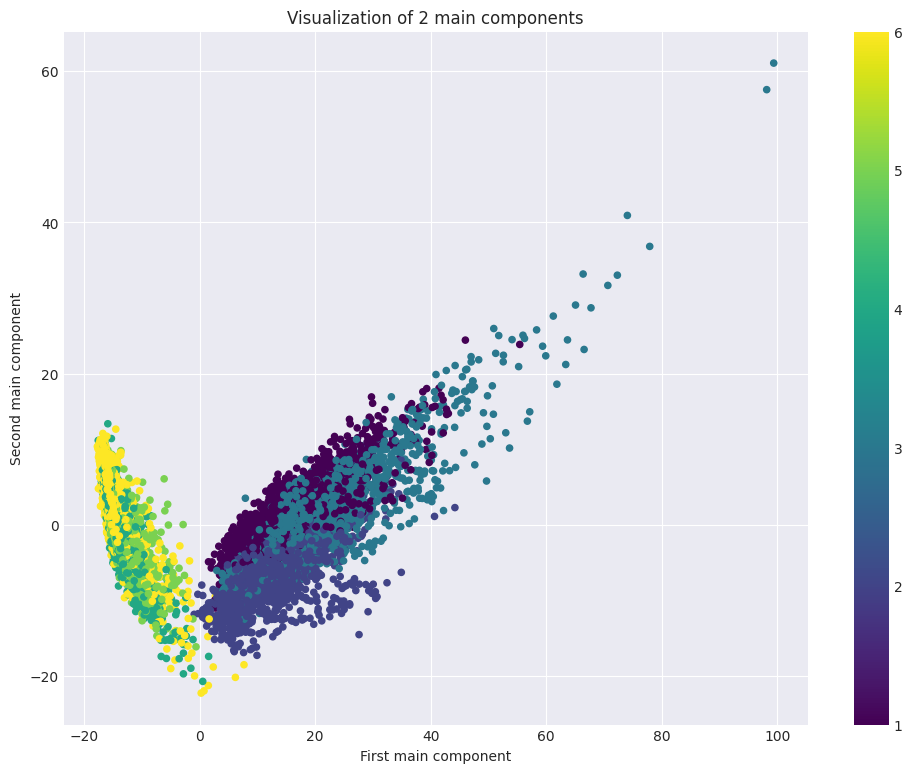

In [92]:


plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis');

cbar =plt.colorbar(ticks=np.unique(y))
plt.title("Visualization of 2 main components")
plt.xlabel("First main component")
plt.ylabel("Second main component")
plt.show()


**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 1 кластер: все 6 активностей
- **2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)**
- 3 кластера: (ходьба), (подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)
- 6 кластеров

------------------------------

**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

In [111]:
class myKMeans:
  def __init__(self, n_clasters=8, n_init=100,max_iter=300, tol=1e-4, random_state=None):
    self.n_clasters = n_clasters
    self.n_init = n_init
    self.max_iter = max_iter
    self.tol =tol
    self.random_state=random_state

    self.inertia = np.inf
    self.centers = None
    self.labels = None


  def fit(self, X, y=None):

    best_inertia = self.inertia
    best_centers = None
    best_labels = None


    if self.random_state is not None:
      np.random.seed(self.random_state)

    for i in range(self.n_init):

      random_dot = np.random.permutation(X.shape[0])[:self.n_clasters]
      centroids = X[random_dot]

      for j in range(self.max_iter):

        distance = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

        labels = np.argmin(distance, axis=1)

        new_centroid = np.array([
            X[labels == k].mean(axis=0) if np.sum(labels == k) > 0 else centroids[random_dot]
            for k in range(self.n_clasters)
        ])

        if np.allclose(centroids, new_centroid):
          break

        centroids = new_centroid

      distances1 = np.min(distance, axis=1)
      _inertia = np.sum(distances1 ** 2)

      if _inertia < best_inertia:
        best_inertia = _inertia
        best_centers = centroids
        best_labels = labels
    self.inertia = best_inertia
    self.centers = best_centers
    self.labels = best_labels

    return self


In [133]:

my_Kmean = myKMeans(n_clasters=6, n_init=100, random_state=RANDOM_STATE)
my_Kmean.fit(X_pca)

print(f"my {my_Kmean.inertia:.1f}")

my 2003454.2


In [116]:
mainKmeans = KMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)
mainKmeans.fit(X_pca)

print(f"not my {mainKmeans.inertia_:.1f}")

not my 2003454.9


Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

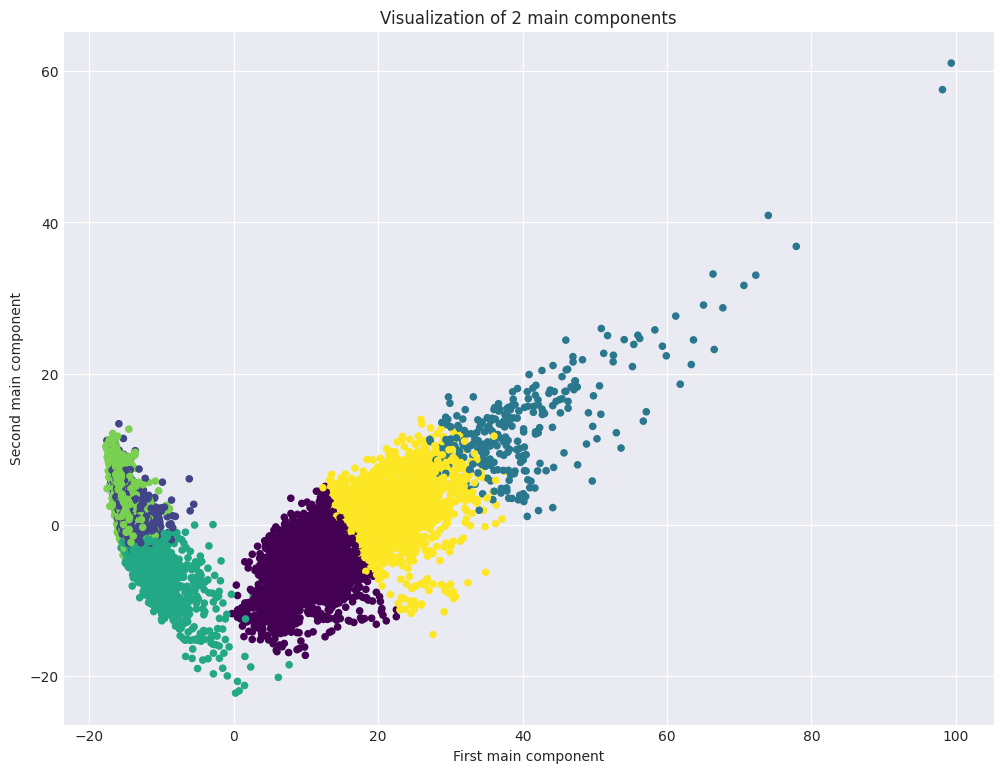

In [118]:


plt.scatter(X_pca[:, 0], X_pca[:, 1], c=my_Kmean.labels, s=20, cmap='viridis');


plt.title("Visualization of 2 main components")
plt.xlabel("First main component")
plt.ylabel("Second main component")
plt.show()


Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [121]:
tab = pd.crosstab(y, my_Kmean.labels, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,все
ходьба,901,0,78,0,0,743,1722
подъем вверх по лестнице,1239,0,5,2,0,298,1544
спуск по лестнице,319,0,196,0,0,891,1406
сидение,1,1235,0,450,91,0,1777
стояние,0,1344,0,562,0,0,1906
лежание,5,52,0,329,1558,0,1944
все,2465,2631,279,1343,1649,1932,10299


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- ходьба
- стояние
- спуск по лестнице
- **перечисленные варианты не подходят**

спуск по лестнице 891/1406 $\approx$ 0.63

ходьба 901/1722 $\approx$ 0.52

стояние 1344/1906 $\approx$ 0.7

все объекты не идеально распределились

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

In [122]:
inertia = []
for k in tqdm_notebook(range(1, n_classes + 1)):
  myKmeans_ = myKMeans(n_clasters=k, n_init=100, random_state=RANDOM_STATE)
  myKmeans_.fit(X_pca)
  inertia.append(myKmeans_.inertia)

/tmp/ipython-input-2805650302.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(range(1, n_classes + 1)):


  0%|          | 0/6 [00:00<?, ?it/s]

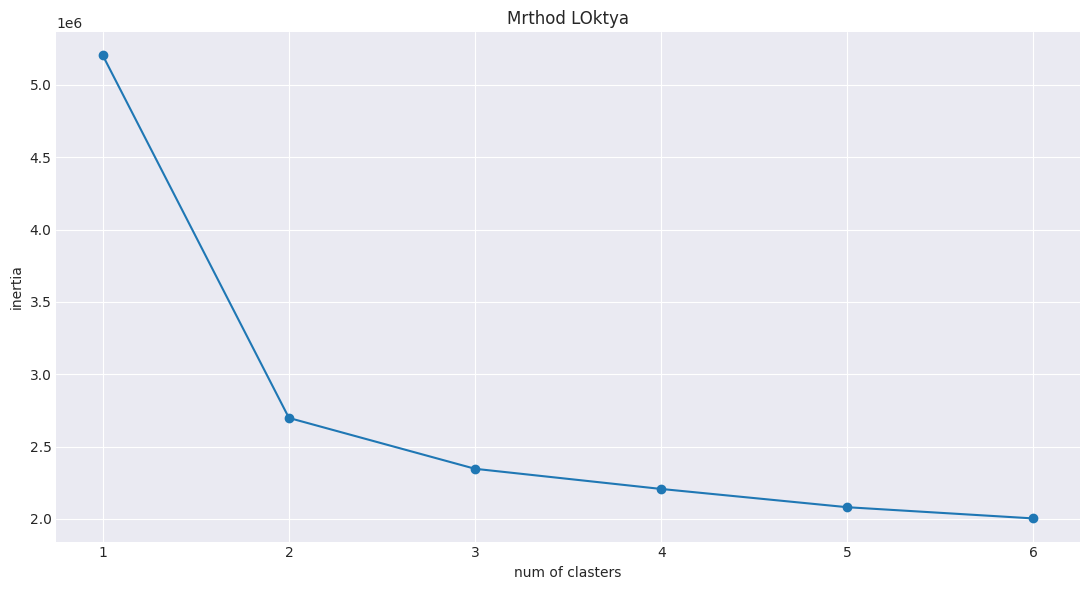

In [131]:
fig = plt.figure(figsize=(11,6))

plt.plot(range(1, n_classes + 1), inertia, marker='o')
plt.title("Mrthod LOktya")
plt.xlabel("num of clasters")
plt.ylabel("inertia")
plt.tight_layout()
plt.show()


**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 1
- **2**
- 3
- 4

потому что при 2 кластерах inertia перестает существенно уменьшаться

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [132]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

In [138]:
my_ari = metrics.adjusted_rand_score(ag.labels_, my_Kmean.labels)

print(f"my ari: {my_ari:.2f}")

nm_ari = metrics.adjusted_rand_score(ag.labels_, mainKmeans.labels_)
print(f"notm ya ri: {nm_ari:.2f}")

my ari: 0.69
notm ya ri: 0.69


**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Варианты:**
- Согласно ARI, KMeans справился с кластеризацией хуже, чем Agglomerative Clustering
- **Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры**
- **В случае случайного разбиения на кластеры ARI будет близок к нулю**

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [144]:
new_scaler = StandardScaler()
X_train_scaled = new_scaler.fit_transform(X_train)
X_test_scaled = new_scaler.fit_transform(X_test)

In [145]:
svc = LinearSVC(max_iter=10000, random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

In [146]:
grid_search = GridSearchCV(svc, svc_params, cv=3)
grid_search.fit(X_train_scaled, y_train)
best_svc =grid_search.best_estimator_
print(best_svc)

LinearSVC(C=0.1, max_iter=10000, random_state=17)


**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.001
- 0.01
- **0.1**
- 1
- 10

In [147]:
y_predicted = best_svc.predict(X_test_scaled)

In [148]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,479,11,4,2,0,0,496
подъем вверх по лестнице,4,465,1,1,0,0,471
спуск по лестнице,1,2,416,1,0,0,420
сидение,0,4,0,433,52,2,491
стояние,0,0,0,16,516,0,532
лежание,0,0,0,0,7,530,537
все,484,482,421,453,575,532,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**Ответ:**
- по точности – подъем вверх по лестнице, по полноте – лежание
- по точности – лежание, по полноте – сидение
- по точности – ходьба, по полноте – ходьба
- **по точности – сидение, по полноте – стояние**

Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Варианты:**
- Качество одинаковое
- 2%
- **4%**
- 10%
- 20%


In [151]:
pca = PCA(n_components=0.90,random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.fit_transform(X_test_scaled)

grid_search1 = GridSearchCV(svc, svc_params, cv=3)
grid_search1.fit(X_train_pca, y_train)
best_svc1 =grid_search1.best_estimator_
print(grid_search.best_score_)
print(grid_search1.best_score_)

print(f"{round(abs(grid_search.best_score_ - grid_search1.best_score_) * 100)}")

0.9379785010699506
0.8983982658750974
4


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Варианты:**
- Метод главных компонент в данном случае позволил уменьшить время обучения модели, при этом качество (доля верных ответов на кросс-валидации) очень пострадало, более чем на 10%
- **PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность**
- **PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком**

**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

In [163]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

In [164]:
dbScan = DBSCAN(eps=3, min_samples=10)
clasters_db = dbScan.fit_predict(X_tsne)


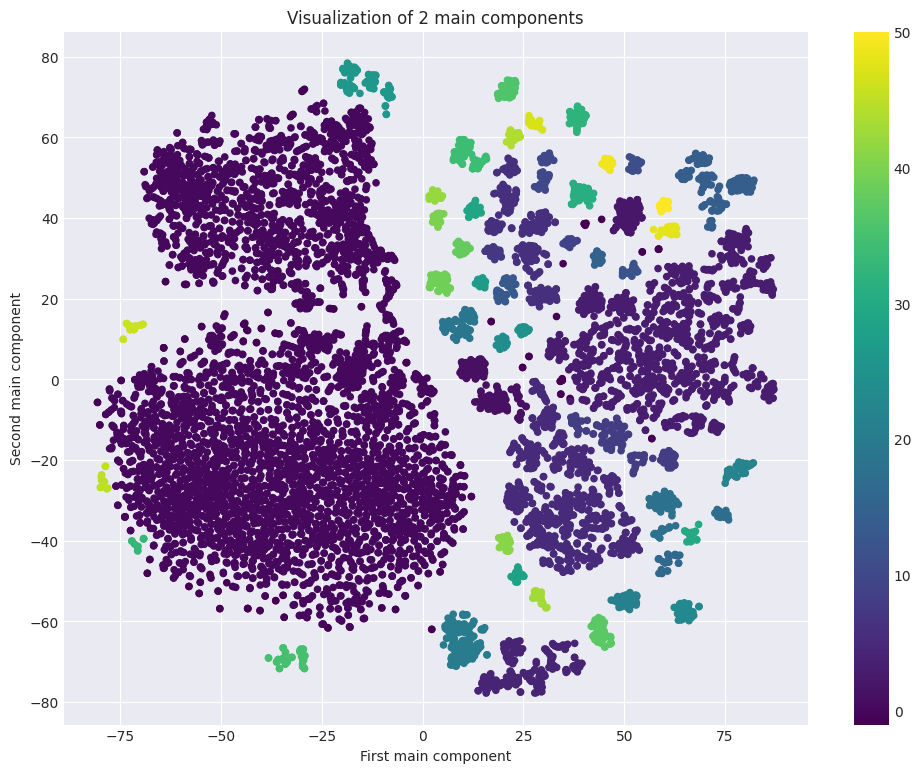

In [167]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clasters_db, s=20, cmap='viridis');

plt.colorbar()
plt.title("Visualization of 2 main components")
plt.xlabel("First main component")
plt.ylabel("Second main component")
plt.show()
